### 小实战: 从零开始梯度下降到线性回归

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)
print("success")

success


### 加载diabetes数据集
- diabetes
数据集是sklearn
内置的经典的回归数据集
- 样本数: 442
个病人
- 特征数: 10
个基线变量
- 目标: 一年后疾病进展的量化标准指标(连续值可以回归)
- 关键优点: 特征已经标准化(均值0, 方差1), 对于梯度下降非常重要-否则不同的量纲会让loss曲线变成一个下厂峡谷, 梯度下降会震荡难以收敛
- 命名约定: 真实数据用X, y, 后面合成数据xs, ys 互不干扰


In [16]:
data = load_diabetes()
X, y = data['data'], data['target']
print(X.shape, y.shape)
print("y的形状", y.shape)
print('特征名:', data['feature_names'])
print('X 均值', X.mean(axis=0).round(3))
print('X 标准差', X.std(axis=0).round(3))

(442, 10) (442,)
y的形状 (442,)
特征名: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X 均值 [-0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]
X 标准差 [0.048 0.048 0.048 0.048 0.048 0.048 0.048 0.048 0.048 0.048]


In [17]:
print('y 的范围', y.min(), '~', y.max())
print("样本数是否一致:", X.shape[0] == y.shape[0])

y 的范围 25.0 ~ 346.0
样本数是否一致: True


## 一元线性回归(合成数据)


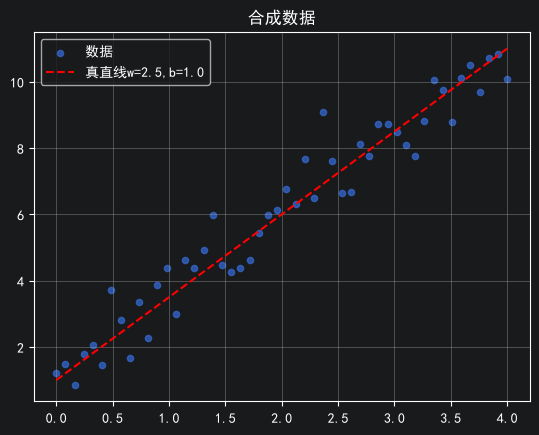

In [18]:
# 手写一条带噪声的直线(合成数据xs,ys)

true_w, true_b = 2.5, 1.0
xs = np.linspace(0, 4, 50)
ys = true_w * xs + true_b + np.random.randn(50) * 0.8

plt.scatter(xs, ys, s=20, alpha=0.7, label='数据')
plt.plot(xs, true_w * xs + true_b, 'r--', label=f'真直线w={true_w},b={true_b}')
plt.legend()
plt.grid(True)
plt.title('合成数据')
plt.show()


## 手写梯度下降
损失函数 MSE：$L(w,b) = \frac{1}{n}\sum_i (w\cdot x_i+b - y_i)^2$

对 w 和 b 求偏导（这就是梯度！）：
- $\frac{\partial L}{\partial w} = \frac{2}{n}\sum_i x_i(wx_i+b-y_i)$
- $\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (wx_i+b-y_i)$
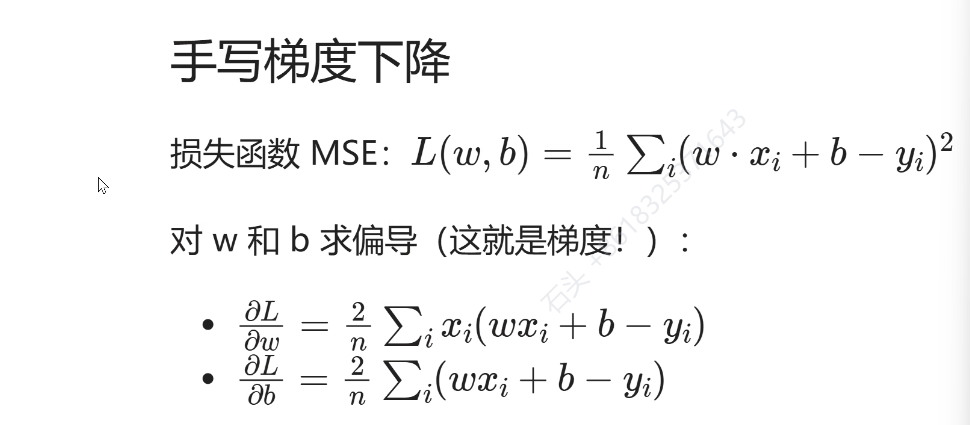
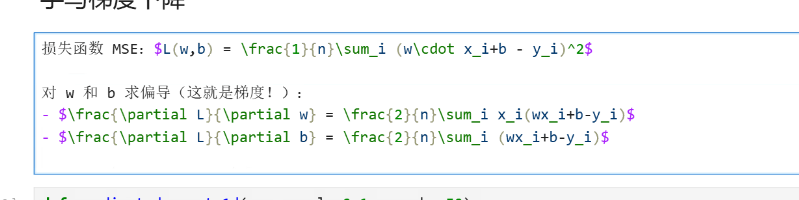

In [32]:
# 梯度等于偏导数组成的向量
def gradient_descent_1d(xs, ys, lr=0.1, epochs=100):
    """
    模拟梯度下降
    :param xs: 输入特征
    :param ys: 真实标签
    :param lr: 学习率
    :param epochs: 迭代次数
    :return:
    """
    #  初始化
    w, b = 0.0, 0.0
    # 用于记录每次迭代之后的参数
    history = [(w, b)]
    # 记录么此迭代的损失值,误差
    losses = []
    # 获取样本总数
    n = len(xs)
    for _ in range(epochs):
        pred = w * xs + b
        err = pred - ys
        # 计算梯度
        dw = (2 / n) * np.sum(xs * err)
        db = (2 / n) * np.sum(err)
        # 更新参数
        w -= lr * dw
        b -= lr * db
        history.append((w, b))
        losses.append(np.mean(err ** 2))
    return w, b, np.array(history), np.array(losses)


w1, b1, hist, losses1 = gradient_descent_1d(xs, ys, lr=0.1, epochs=100)
print(f'学到的:w={w1:.4f},b={b1:.4f} (真值:w={true_w},b={true_b})')
print(f'最终的loss:{losses1[-1]:.4f}')


学到的:w=2.3965,b=1.2734 (真值:w=2.5,b=1.0)
最终的loss:0.4858


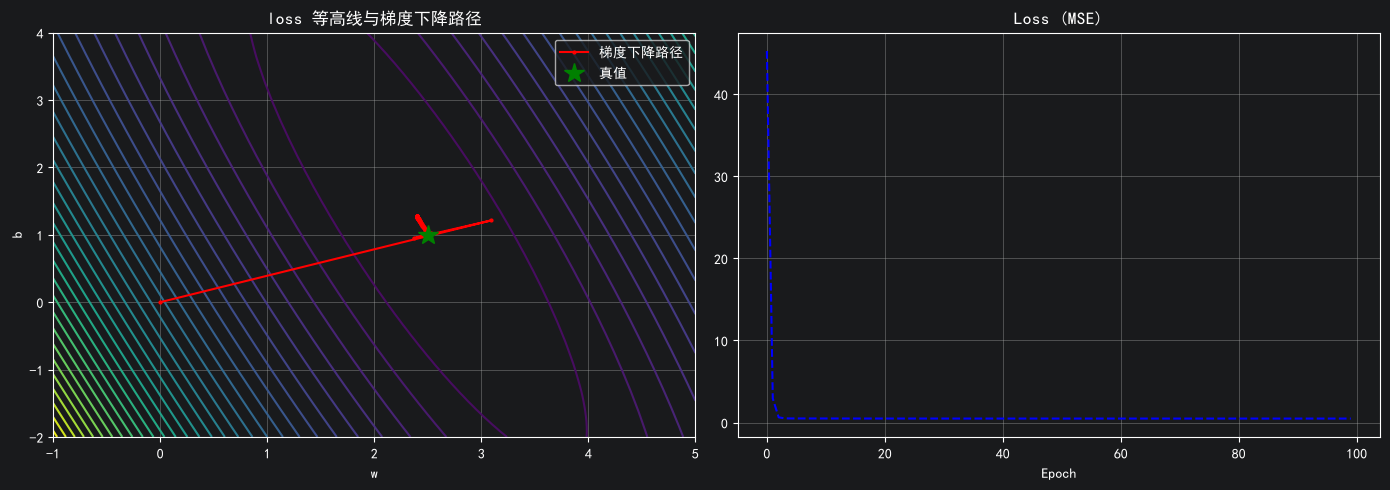

In [53]:
W = np.linspace(-1, 5, 80)
B = np.linspace(-2, 4, 80)

Wg, Bg = np.meshgrid(W, B)
Lg = np.mean((Wg[:, :, None] * xs[None, None, :] + Bg[:, :, None] - ys[None, None, :]) ** 2, axis=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.contour(Wg, Bg, Lg, 30, cmap='viridis')
ax.plot(hist[:, 0], hist[:, 1], 'r.-', markersize=4, label='梯度下降路径')
ax.plot(true_w, true_b, 'g*', markersize=15, label='真值')
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_title("loss 等高线与梯度下降路径")

ax.legend()
ax.grid(True)
axes[1].plot(losses1, 'b--')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Loss (MSE)')
axes[1].grid(True)

plt.tight_layout()
plt.show()



###  多元线性回归(使用diabetes真实数据)

In [37]:
print(X.shape, y.shape)

(442, 10) (442,)


In [40]:
# 划分数据集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("训练集:", X_train.shape, y_train.shape)
print("测试集:", X_test.shape, y_test.shape)

训练集: (353, 10) (353,)
测试集: (89, 10) (89,)


In [44]:
# 梯度等于偏导数组成的向量
from sklearn.metrics import mean_squared_error


def gradient_descent_multi(X, y, lr=0.5, epochs=100):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for _ in range(epochs):
        pred = w @ X.T + b
        err = pred - y
        # 计算偏导
        dw = (2 / n) * np.sum(X.T @ err)
        db = (2 / n) * np.sum(err)
        # 更新参数
        w -= lr * dw
        b -= lr * db
        losses.append(np.mean(err ** 2))
    return w, b, np.array(losses)


w, b, loesses2 = gradient_descent_multi(X_train, y_train, lr=0.5, epochs=100)
print(f'学到的:w={w.round(2)}')
print(f'偏置:b = {b:.2f}')
print(f"训练 loss:{loesses2[-1]:.2f}")

pred_test = X_test @ w + b
test_mse = mean_squared_error(y_test, pred_test)
print(f"测试MSE:{test_mse:.2f}")

学到的:w=[150.41 150.41 150.41 150.41 150.41 150.41 150.41 150.41 150.41 150.41]
偏置:b = 152.88
训练 loss:4622.09
测试MSE:3985.78


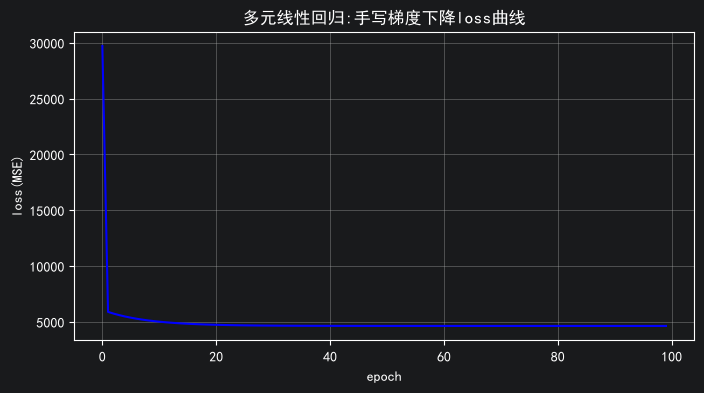

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(loesses2, 'b-')
plt.xlabel('epoch')
plt.ylabel("loss(MSE)")
plt.title("多元线性回归:手写梯度下降loss曲线")
plt.grid(True)
plt.show()

###  与sklearn做对比
- sklearn 内部linearregression


In [51]:
# sklearn 基准
sk = LinearRegression()
sk.fit(X_train, y_train)
sk_pred = sk.predict(X_test)
sk_mse = mean_squared_error(y_test, sk_pred)

print(f"手写梯度下降 测试MSE={test_mse:.2f}")
print(f"sklearn 最小二乘法 测试MSE={sk_mse:.2f}")

print(f"偏置差异: {abs(b - sk.intercept_):.4f}")

手写梯度下降 测试MSE=3985.78
sklearn 最小二乘法 测试MSE=2900.19
偏置差异: 1.5376


lr=1.2 时 序列前10:[   29711.32    52015.52    96244.61   183307.34   354230.64   689466.13
  1346738.56  2635239.95  5161068.89 10112326.42]
lr=1.2 时 最终 loss:2052605348609244210205104204152832.00(若为nan/inf为发散)


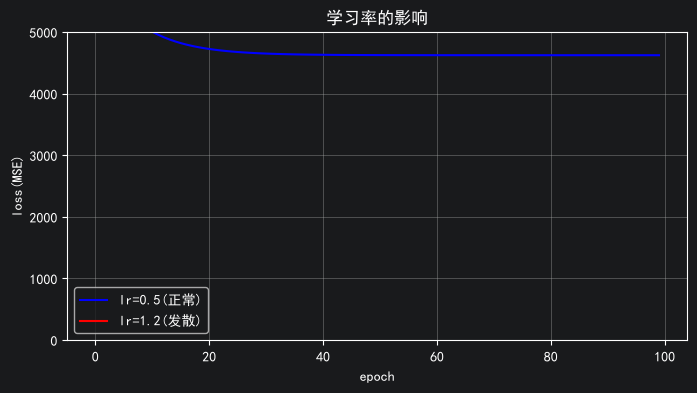

In [61]:
## 学习率过大会发散
_, _, losses_big = gradient_descent_multi(X_train, y_train, lr=1.2, epochs=100)
print(f'lr=1.2 时 序列前10:{losses_big[:10].round(2)}')
print(f'lr=1.2 时 最终 loss:{losses_big[-1]:.2f}(若为nan/inf为发散)')

plt.figure(figsize=(8, 4))
plt.plot(loesses2, 'b-', label='lr=0.5(正常)')
plt.plot(losses_big, 'r-', label='lr=1.2(发散)')
plt.ylim(0, min(5000, max(loesses2[-1] * 3, 1)))
plt.xlabel('epoch')
plt.ylabel("loss(MSE)")
plt.title('学习率的影响')
plt.legend()
plt.grid(True)
plt.show()

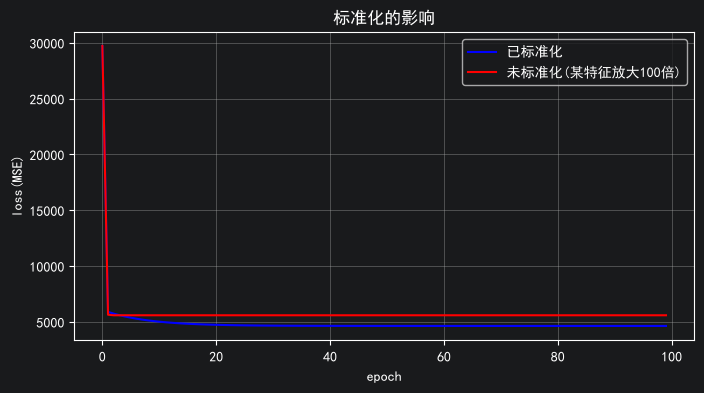

In [66]:
### 反标准化
X_bad = X_train.copy()
X_bad[:,0] *=20
_, _, losses_bad = gradient_descent_multi(X_bad, y_train, lr=0.5, epochs=100)

plt.figure(figsize=(8, 4))
plt.plot(loesses2, 'b-', label='已标准化')
plt.plot(losses_bad, 'r-', label='未标准化(某特征放大100倍)')

plt.xlabel('epoch')
plt.ylabel("loss(MSE)")
plt.title('标准化的影响')
plt.legend()
plt.grid(True)
plt.show()

### 作业
- 作业1:把学习率变成0.1,0.3,0.5,画四条loss曲线对比
- 作业2: 尝试用sklearn 的California  Housing 数据集,注意先做标准化
- 作业3: 为什么不用解析的解而用梯度下降(参数量)

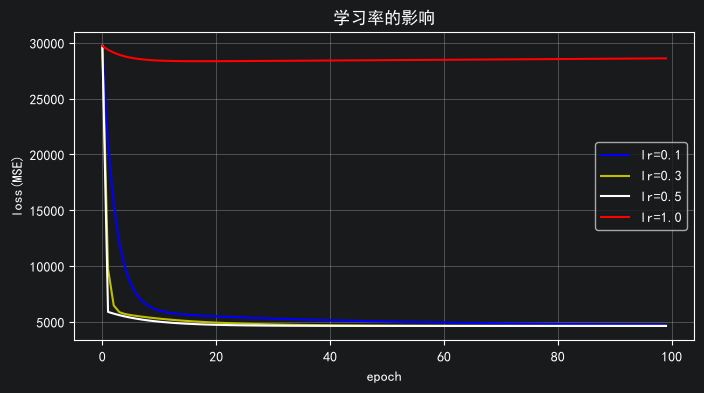

In [68]:
# 作业1:把学习率变成0.1,0.3,0.5,画四条loss曲线对比
_, _, losses_1 = gradient_descent_multi(X_train, y_train, lr=0.1, epochs=100)
_, _, losses_2 = gradient_descent_multi(X_train, y_train, lr=0.3, epochs=100)
_, _, losses_3 = gradient_descent_multi(X_train, y_train, lr=0.5, epochs=100)
_, _, losses_4 = gradient_descent_multi(X_train, y_train, lr=1.0, epochs=100)

plt.figure(figsize=(8, 4))
plt.plot(losses_1, 'b-', label='lr=0.1')
plt.plot(losses_2, 'y-', label='lr=0.3')
plt.plot(losses_3, 'w-', label='lr=0.5')
plt.plot(losses_4, 'r-', label='lr=1.0')
plt.xlabel('epoch')
plt.ylabel("loss(MSE)")
plt.title('学习率的影响')
plt.legend()
plt.grid(True)
plt.show()

(20640, 8) (20640,)
y的形状 (20640,)
特征名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
训练集: (16512, 8) (16512,)
测试集: (4128, 8) (4128,)
学到的:w=[0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11]
偏置:b = 2.07
训练 loss:34268152608422798386702547992197236316680543294459516277370335637600308782822363525016421939393442260990893099687754200621466978400324718817922913402880.00
训练 loss:1.25
测试MSE:1.25


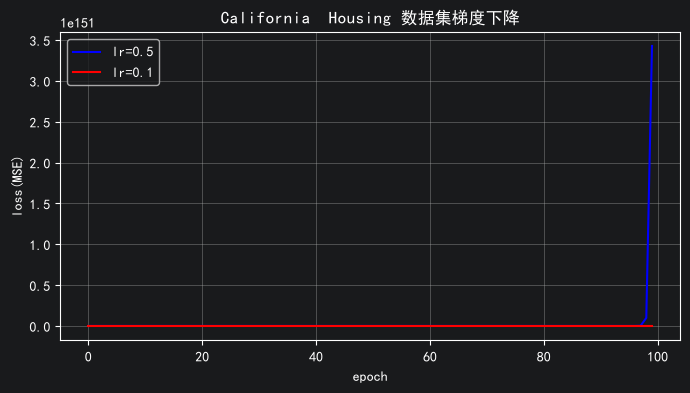

In [84]:
# 作业2: 尝试用sklearn 的California  Housing 数据集,注意先做标准化

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# 加载数据
data =  fetch_california_housing()
X, y = data['data'], data['target']
print(X.shape, y.shape)
print("y的形状", y.shape)
print('特征名:', data['feature_names'])

#  实现数据集的划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("训练集:", X_train.shape, y_train.shape)
print("测试集:", X_test.shape, y_test.shape)

# 实现数据的标准化

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


w, b, losses_01 = gradient_descent_multi(X_train, y_train, lr=0.5, epochs=100)
w, b, losses_02 = gradient_descent_multi(X_train, y_train, lr=0.1, epochs=100)
print(f'学到的:w={w.round(2)}')
print(f'偏置:b = {b:.2f}')
print(f"训练 loss:{losses_01[-1]:.2f}")
print(f"训练 loss:{losses_02[-1]:.2f}")

pred_test = X_test @ w + b
test_mse = mean_squared_error(y_test, pred_test)
print(f"测试MSE:{test_mse:.2f}")

# 可视化
plt.figure(figsize=(8, 4))
plt.plot(losses_01, 'b-', label='lr=0.5')
plt.plot(losses_02, 'r-', label='lr=0.1')
plt.xlabel('epoch')
plt.ylabel("loss(MSE)")
plt.title('California  Housing 数据集梯度下降')
plt.legend()
plt.grid(True)
plt.show()



# 作业3: 为什么不用解析的解而用梯度下降(参数量)
1. 数据量过于庞大计算成本太高
2. 一些复杂的模型是无法直接求解的反向